# CSC172 Data Mining and Analysis Final Project Notebook

In [69]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import seaborn as sns
import pandas as pd
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore', category=DeprecationWarning)

## Data Preprocessing

In [70]:
df = pd.read_csv("./data/bread_basket.csv")

In [71]:
df.head()


,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,30-10-2016 09:58,morning,weekend
1,2,Scandinavian,30-10-2016 10:05,morning,weekend
2,2,Scandinavian,30-10-2016 10:05,morning,weekend
3,3,Hot chocolate,30-10-2016 10:07,morning,weekend
4,3,Jam,30-10-2016 10:07,morning,weekend


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


In [73]:
print(f"Number of Unique Transactions: {df['Transaction'].nunique()}")
print(f"Number of Unique Items: {df['Item'].nunique()}")

Number of Unique Transactions: 9465
Number of Unique Items: 94


Convert the date_time column to a datetime array to enable us to separate the date and time information

In [74]:
df["date_time"] = pd.to_datetime(df["date_time"],dayfirst=True)
df["date_time"].unique()

<DatetimeArray>
['2016-10-30 09:58:00', '2016-10-30 10:05:00', '2016-10-30 10:07:00',
 '2016-10-30 10:08:00', '2016-10-30 10:13:00', '2016-10-30 10:16:00',
 '2016-10-30 10:19:00', '2016-10-30 10:20:00', '2016-10-30 10:21:00',
 '2016-10-30 10:25:00',
 ...
 '2017-04-09 13:04:00', '2017-04-09 13:06:00', '2017-04-09 13:20:00',
 '2017-04-09 13:49:00', '2017-04-09 14:08:00', '2017-04-09 14:24:00',
 '2017-04-09 14:30:00', '2017-04-09 14:32:00', '2017-04-09 14:57:00',
 '2017-04-09 15:04:00']
Length: 9182, dtype: datetime64[ns]

In [75]:
df['date']= df['date_time'].dt.date
df['time']= df['date_time'].dt.time
df['month']= df['date_time'].dt.month
df['month'] = df['month'].replace((1,2,3,4,5,6,7,8,9,10,11,12), ('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug', 'Sep','Oct','Nov','Dec'))
df['month'].unique()

array(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr'], dtype=object)

In [76]:
df['hour']= df['date_time'].dt.hour
df['hour'].unique()

array([ 9, 10, 11, 12, 13, 14,  8, 15, 17, 18,  7, 16, 19, 20, 21,  1, 23,
       22], dtype=int32)

We won't keep tabs on the minutes, as such the code above, but we will convert these integer hour values that exist to strings that represent the range of the time they are in. 

In [77]:
hr_int = (1,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23)
hr_str = ("1-2", "7-8", "8-9", "9-10", "10-11", "11-12", "12-13", "13-14", "14-15", "15-16", "16-17", "17-18", "18-19", "19-20", "20-21", "21-22", "22-23", "23-24")
df['hour'] = df['hour'].replace(hr_int, hr_str)

In [78]:
# Data processing
df['day_of_the_week']= df['date_time'].dt.weekday
df['day_of_the_week']= df['day_of_the_week'].replace((0,1,2,3,4,5,6),("Mon", "Tues", "Wed", "Thur", "Fri", "Sat", "Sun"))
df.drop('date_time', axis=1, inplace=True)

df.head()

,Transaction,Item,period_day,weekday_weekend,date,time,month,hour,day_of_the_week
0,1,Bread,morning,weekend,2016-10-30,09:58:00,Oct,9-10,Sun
1,2,Scandinavian,morning,weekend,2016-10-30,10:05:00,Oct,10-11,Sun
2,2,Scandinavian,morning,weekend,2016-10-30,10:05:00,Oct,10-11,Sun
3,3,Hot chocolate,morning,weekend,2016-10-30,10:07:00,Oct,10-11,Sun
4,3,Jam,morning,weekend,2016-10-30,10:07:00,Oct,10-11,Sun


In [79]:
# Clean items column
df['Item']=df['Item'].str.strip()
df['Item']=df['Item'].str.lower()
df.head()

,Transaction,Item,period_day,weekday_weekend,date,time,month,hour,day_of_the_week
0,1,bread,morning,weekend,2016-10-30,09:58:00,Oct,9-10,Sun
1,2,scandinavian,morning,weekend,2016-10-30,10:05:00,Oct,10-11,Sun
2,2,scandinavian,morning,weekend,2016-10-30,10:05:00,Oct,10-11,Sun
3,3,hot chocolate,morning,weekend,2016-10-30,10:07:00,Oct,10-11,Sun
4,3,jam,morning,weekend,2016-10-30,10:07:00,Oct,10-11,Sun


The dataset already had no missing values, as seen in df.info(), modified it to separated the date_time column to better see temporal patterns in the dataset later, and normalized the formatting for the item column

## Exploratory Data Analysis and Visualization

In [80]:
df['Item'].value_counts()

Item
coffee            5471
bread             3325
tea               1435
cake              1025
pastry             856
                  ... 
adjustment           1
the bart             1
olum & polenta       1
gift voucher         1
raw bars             1
Name: count, Length: 94, dtype: int64

C:\Users\Admin\AppData\Local\Temp\ipykernel_14560\3423908315.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.Item.value_counts().head(10).index, y=df.Item.value_counts().head(10).values,palette='RdYlGn')


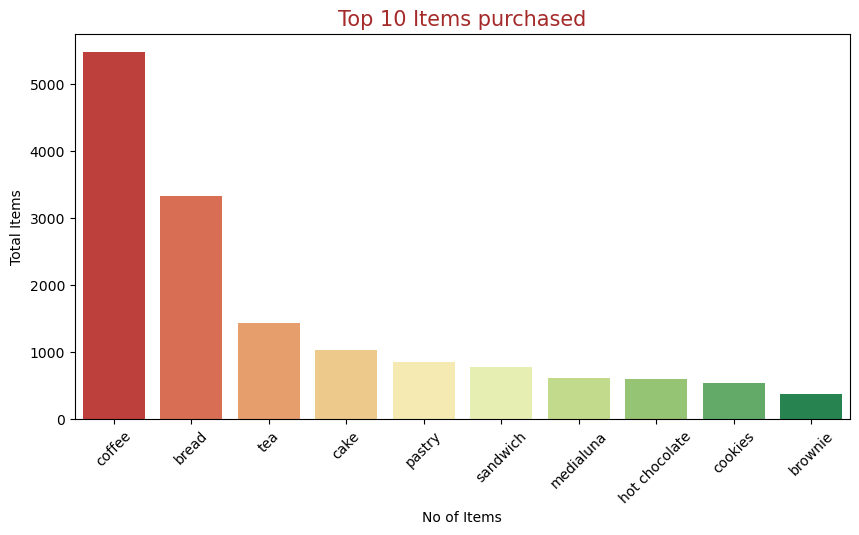

In [81]:
plt.figure(figsize=(10,5))
sns.barplot(x=df.Item.value_counts().head(10).index, y=df.Item.value_counts().head(10).values,palette='RdYlGn')
plt.xlabel('No of Items', size = 10)
plt.xticks(rotation=45)
plt.ylabel('Total Items', size = 10)
plt.title('Top 10 Items purchased', color = 'Brown', size = 15)
plt.show()

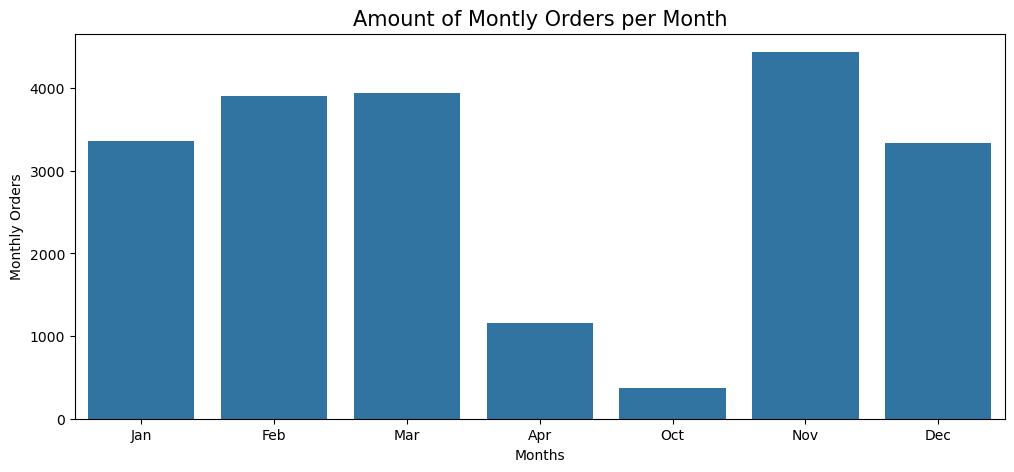

In [82]:
month_order = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

mon_Tran =df.groupby('month')['Transaction'].count().reset_index()
mon_Tran.head(20)
mon_Tran['mon_order'] = mon_Tran['month'].map(month_order)
mon_Tran.sort_values("mon_order",inplace=True)

plt.figure(figsize=(12,5))
sns.barplot(data = mon_Tran, x = "month", y = "Transaction")
plt.xlabel('Months', size = 10)
plt.ylabel('Monthly Orders', size = 10)
plt.title('Amount of Montly Orders per Month', color = 'black', size = 15)
plt.show()
